# Config


In [65]:
import pandas as pd
import os
from dotenv import load_dotenv
from entsoe import EntsoePandasClient

load_dotenv()

# ENTSOE Token
entsoe_token = os.getenv("ENTSOE_API_TOKEN")

# ENTSOE Client
entsoe_client = EntsoePandasClient(api_key=entsoe_token)

# Fetch Actual & FCST Load

In [66]:
# Location
country_capital = "Madrid"
country_code = "ES"


# Period
today = pd.Timestamp.now(
    tz=f"Europe/{country_capital}"
).normalize()

yesterday=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=1)
)
last_week=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=7)
)


start=last_week
end=today

In [67]:
df = entsoe_client.query_load_and_forecast(
    country_code=country_code,
    start=last_week,
    end=today)

df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 672 entries, 2026-07-31 00:00:00+02:00 to 2026-08-06 23:45:00+02:00
Freq: 15min
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Forecasted Load  672 non-null    float64
 1   Actual Load      672 non-null    float64
dtypes: float64(2)
memory usage: 15.8 KB


In [68]:
df.head()

,Forecasted Load,Actual Load
2026-07-31 00:00:00+02:00,32159.0,32004.0
2026-07-31 00:15:00+02:00,31700.0,32000.0
2026-07-31 00:30:00+02:00,31222.0,31472.0
2026-07-31 00:45:00+02:00,30735.0,30860.0
2026-07-31 01:00:00+02:00,30211.0,30300.0


In [69]:
df.tail()


,Forecasted Load,Actual Load
2026-08-06 22:45:00+02:00,33453.0,33128.0
2026-08-06 23:00:00+02:00,32787.0,32464.0
2026-08-06 23:15:00+02:00,32220.0,31944.0
2026-08-06 23:30:00+02:00,31716.0,31352.0
2026-08-06 23:45:00+02:00,31259.0,30800.0


In [ ]:
# Check that timestamps are unique
assert df.index.is_unique

# Check that timestamps are sorted
assert df.index.is_monotonic_increasing/

In [ ]:
df["Date"] = df.index.date

pivot = pd.pivot_table(
    df,
    values=["Actual Load", "Forecasted Load"],
    index="Date",
    aggfunc="mean"
)

pivot["Delta"] = pivot["Actual Load"] - pivot["Forecasted Load"]

print(pivot)

             Actual Load  Forecasted Load       Delta
Date                                                 
2026-07-30  33178.125000     33092.604167   85.520833
2026-07-31  32356.875000     32574.968750 -218.093750
2026-08-01  29188.041667     28830.427083  357.614583
2026-08-02  27173.625000     27285.312500 -111.687500
2026-08-03  30934.208333     31185.552083 -251.343750
2026-08-04  30931.541667     30981.114583  -49.572917
2026-08-05  31208.291667     31244.614583  -36.322917


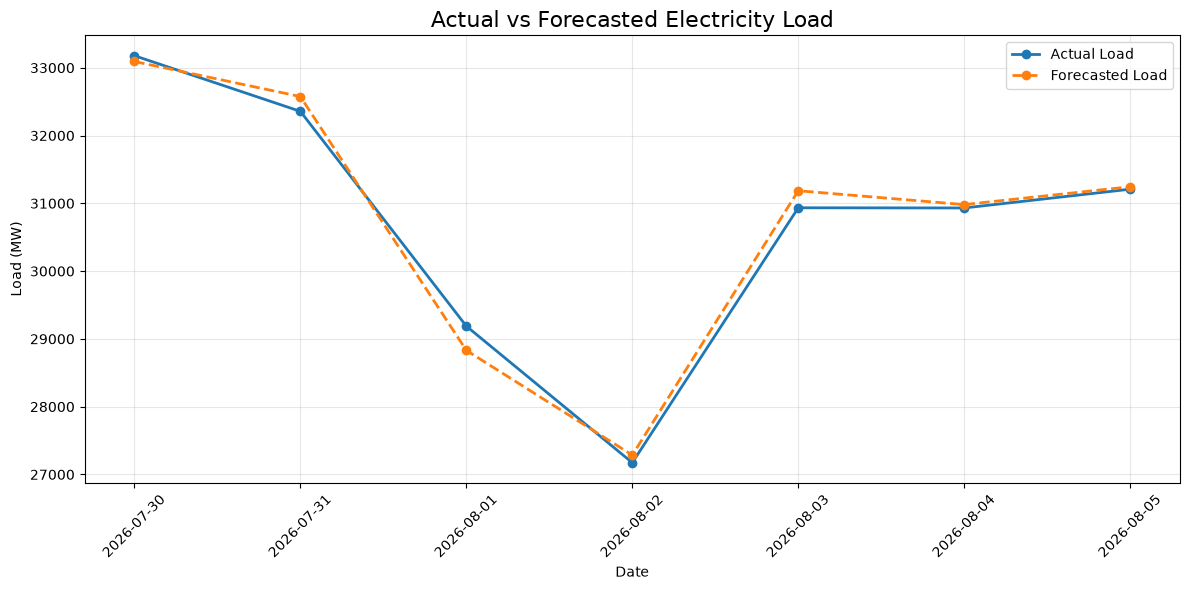

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    pivot.index,
    pivot["Actual Load"],
    marker="o",
    linewidth=2,
    label="Actual Load"
)

plt.plot(
    pivot.index,
    pivot["Forecasted Load"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Forecasted Load"
)

plt.title("Actual vs Forecasted Electricity Load", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

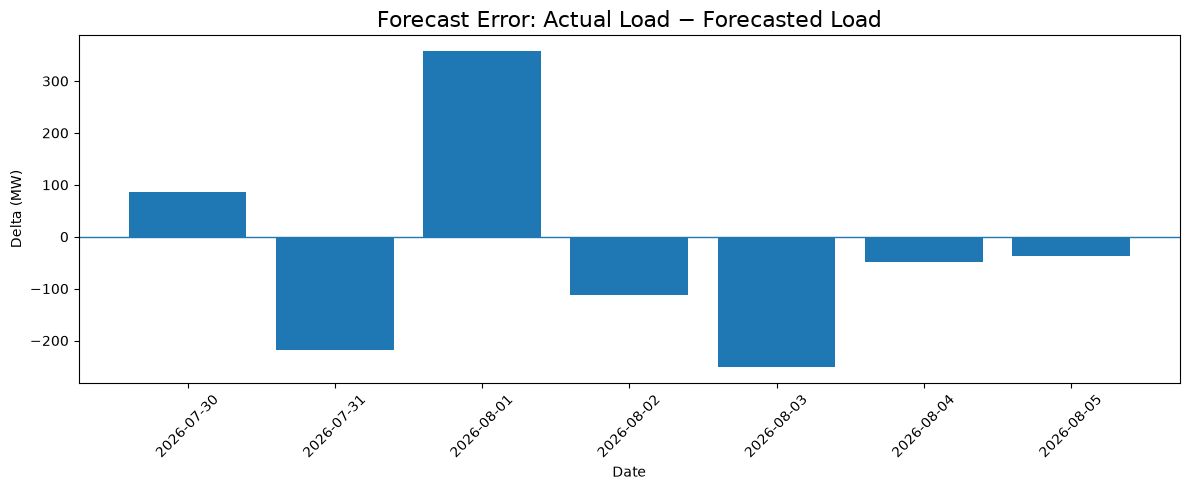

In [ ]:
plt.figure(figsize=(12, 5))

plt.bar(
    pivot.index,
    pivot["Delta"]
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("Forecast Error: Actual Load − Forecasted Load", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Delta (MW)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()